# Figure 4

## Library Imports

In [1]:
import pandas as pd
import numpy as np
import torch
from RnaToProteinDataModule.Dataset_classes import StandardDatasetProcessor
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import seaborn as sns
import sys
import re
import os

## Load and Process Data

**NOTE:** This data was produced via the `RnaToProteinDataModule/scripts/SHAP/2SHAP_horseshoe_plot_generation.py` script *of the `input_residual_connections` branch specifically*. It is reliant on the `0SHAP_run.py` -> `1SHAP_output_consolidation_into_pandas.py` script outputs.

In [2]:
absShapCorrelationFiles = [
    'figure4_datasets/MMP14_category_shap_vs_spearman.csv',
    'figure4_datasets/MMP14_category0_shap_vs_spearman.csv',
    'figure4_datasets/MMP14_category1_shap_vs_spearman.csv',
    'figure4_datasets/MMP14_category2_shap_vs_spearman.csv',
]
absShapCorrelationDfs = [pd.read_csv(file, index_col=0) for file in absShapCorrelationFiles]
absShapCorrelationDfs[0]

,absMeanSHAP,spearman,meanSHAP
AC090022.2,0.000000,NaN,0.000000
SERHL2,0.000838,-0.133037,-0.000838
MIR889,0.000000,NaN,0.000000
SENP3,0.000179,-0.087891,0.000179
AC011243.1,0.000002,-0.189390,0.000002
...,...,...,...
AL035587.2,0.000117,-0.160766,-0.000117
LINC00310,0.000048,-0.447565,-0.000048
AC083760.1,0.000012,-0.039400,0.000012
AC108727.2,0.000013,-0.076642,0.000013


In [3]:
categoryFile = 'figure4_datasets/categories_consensus.tsv'
categoryDict = dict(np.genfromtxt(categoryFile, delimiter='\t', dtype=str))
[categoryDict['MMP14'], categoryDict['A1BG-AS1'], categoryDict['A2ML1-AS1']]

['0', '1', '2']

### Add Transcript Category to Dataframes

In [4]:
for i in range(len(absShapCorrelationDfs)):
    df = absShapCorrelationDfs[i]
    df['category'] = [int(categoryDict[x]) for x in df.index]
    df = df[df['category'] != 3]
    absShapCorrelationDfs[i] = df
absShapCorrelationDfs[0]

,absMeanSHAP,spearman,meanSHAP,category
SERHL2,0.000838,-0.133037,-0.000838,1
SENP3,0.000179,-0.087891,0.000179,0
AC011243.1,0.000002,-0.189390,0.000002,2
SCAMP2,0.000538,-0.363476,-0.000538,0
VTA1,0.000491,0.130986,0.000491,0
...,...,...,...,...
AL035587.2,0.000117,-0.160766,-0.000117,1
LINC00310,0.000048,-0.447565,-0.000048,1
AC083760.1,0.000012,-0.039400,0.000012,2
AC108727.2,0.000013,-0.076642,0.000013,2


### Find logs of absolute mean SHAP

In [5]:
def find_log_of_abs_mean_shap(df):
    arr = np.log(df['absMeanSHAP'])
    shapArr = np.array(df['absMeanSHAP'])
    indexArr = np.array(df.index)
    lowest_non_inf = np.min(arr[np.isfinite(arr)])
    arr[np.isinf(arr)] = lowest_non_inf
    arr[np.isneginf(arr)] = lowest_non_inf
    return arr

In [6]:
for i in range(len(absShapCorrelationDfs)):
    absShapCorrelationDfs[i]['absMeanSHAP'] = find_log_of_abs_mean_shap(absShapCorrelationDfs[i])

/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/lp/2wj_6xhd42n9y8wt7w4_kplm0000gv/T/ipykernel_35137/1049274204.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  absShapCorrelationDfs[i]['absMeanSHAP'] = find_log_of_abs_mean_shap(absShapCorrelationDfs[i])
/Users/cranneyc/miniforge3/envs/nas_paper/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Plots

In [7]:
def plot_and_save(tempDf, filePath):
    mapping = {0: 'direct', 1: 'correlated', 2: 'uncorrelated'}
    tempDf = tempDf.sort_values('category')
    dfCategory = tempDf['category'].map(mapping)
    df = tempDf.copy()
    df['category'] = dfCategory
    plt.clf()
    plt.figure(figsize=(15, 12))
    plot = sns.jointplot(data=df, x='spearman', y='absMeanSHAP', hue='category', kind='kde', palette={'direct': 'blue', 'correlated':'red', 'uncorrelated':'green', 3:'orange'})
    plot.ax_joint.set_ylim(-25.5, -2)
    plt.xlabel('spearman coefficient', fontsize=24)
    plt.ylabel('abs. mean SHAP (log)', fontsize=24)
    plt.xticks(fontsize=24)
    plt.yticks(fontsize=24)
    legend = plot.ax_joint.legend_
    legend.set_title("")
    for text in legend.texts:
        text.set_fontsize(14)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '.' + str(x).split('.')[1][0]))
    plt.savefig(filePath, bbox_inches='tight')
    plt.show()

### No Residual

<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

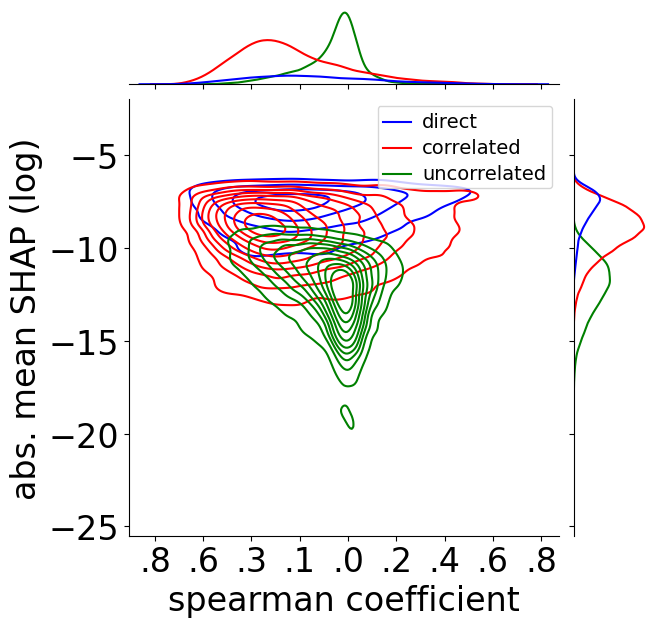

In [8]:
plot_and_save(absShapCorrelationDfs[0], 'figure4_figures/no_residual_kde.svg')

<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

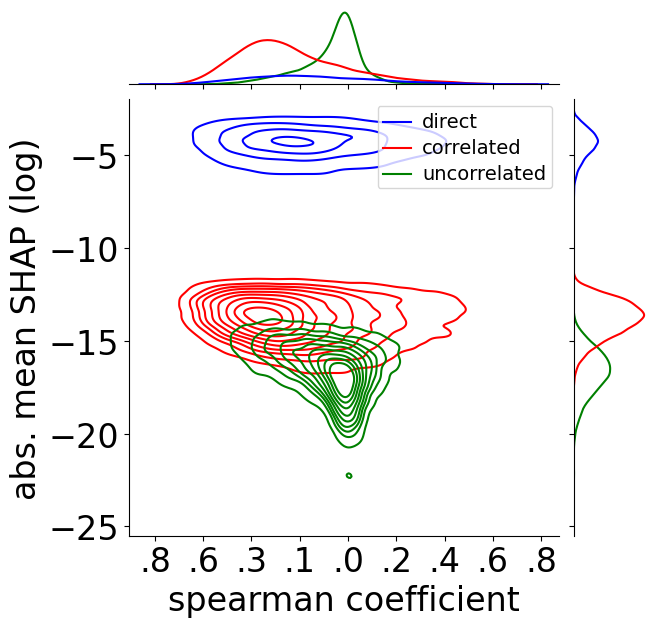

In [9]:
plot_and_save(absShapCorrelationDfs[1], 'figure4_figures/category0_kde.svg')

<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

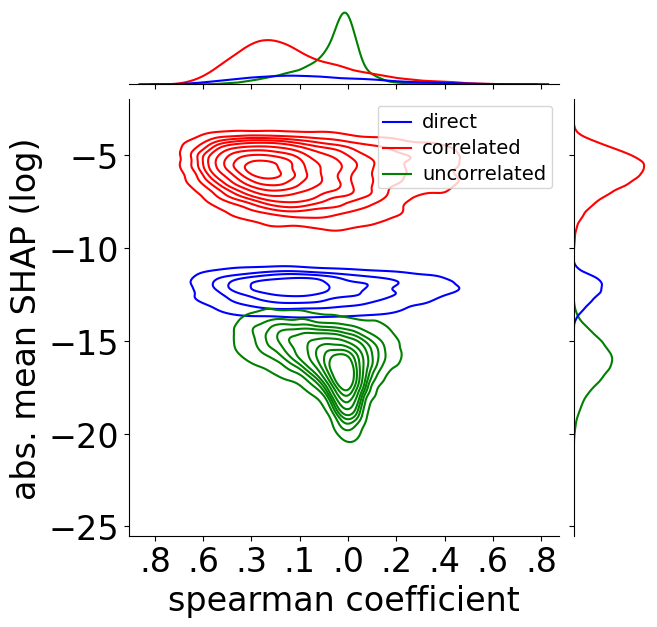

In [10]:
plot_and_save(absShapCorrelationDfs[2], 'figure4_figures/category1_kde.svg')

<Figure size 640x480 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

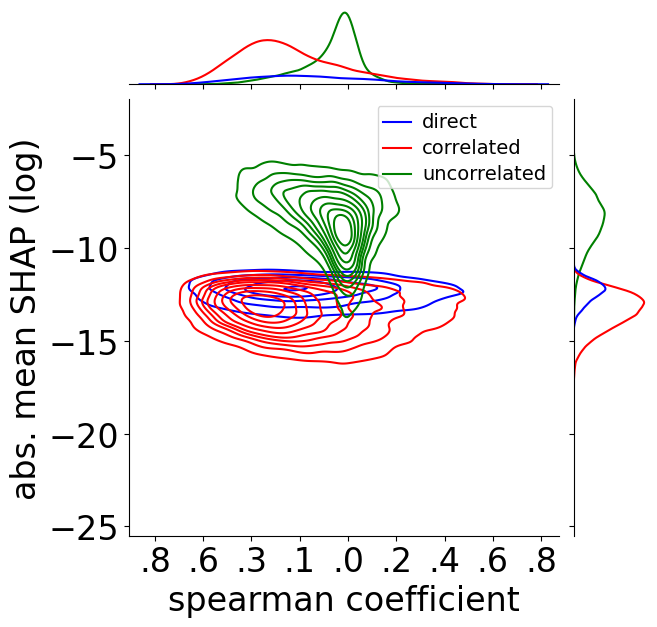

In [11]:
plot_and_save(absShapCorrelationDfs[3], 'figure4_figures/category2_kde.svg')